In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from dowhy import CausalModel
import graphviz as gr
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

C:\Users\mamar9317\AppData\Local\miniconda3\envs\causal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

In [59]:
df = pd.read_csv("babies.csv")
df = df.dropna()
df["bwt"] = df["bwt"] * 0.0283
df["BMI"] = df["weight"] * 0.4536 / ((df["height"]  * 0.0254) ** 2)
df = df.drop(["case", "weight", "height"], axis=1)
df

,bwt,gestation,parity,age,smoke,BMI
0,3.3960,284.0,0,27.0,0.0,18.290359
1,3.1979,282.0,0,33.0,0.0,23.172849
2,3.6224,279.0,0,28.0,1.0,19.739834
4,3.0564,282.0,0,23.0,1.0,19.577896
5,3.8488,286.0,0,25.0,0.0,17.010034
...,...,...,...,...,...,...
1231,3.1979,275.0,1,27.0,0.0,19.530039
1232,3.6224,265.0,0,24.0,0.0,18.794780
1233,3.6790,291.0,0,30.0,1.0,24.961470
1234,3.5375,281.0,1,21.0,0.0,18.305078


In [60]:
X = ["gestation", "parity", "age", "BMI"]
T = "smoke"
Y = "bwt"

#### Bias

In [61]:
df["smoke"].sum()/len(df)

b40% were smoking during pregnancy! We don't know the origins of this dataset. It could be old, or it could be biased.

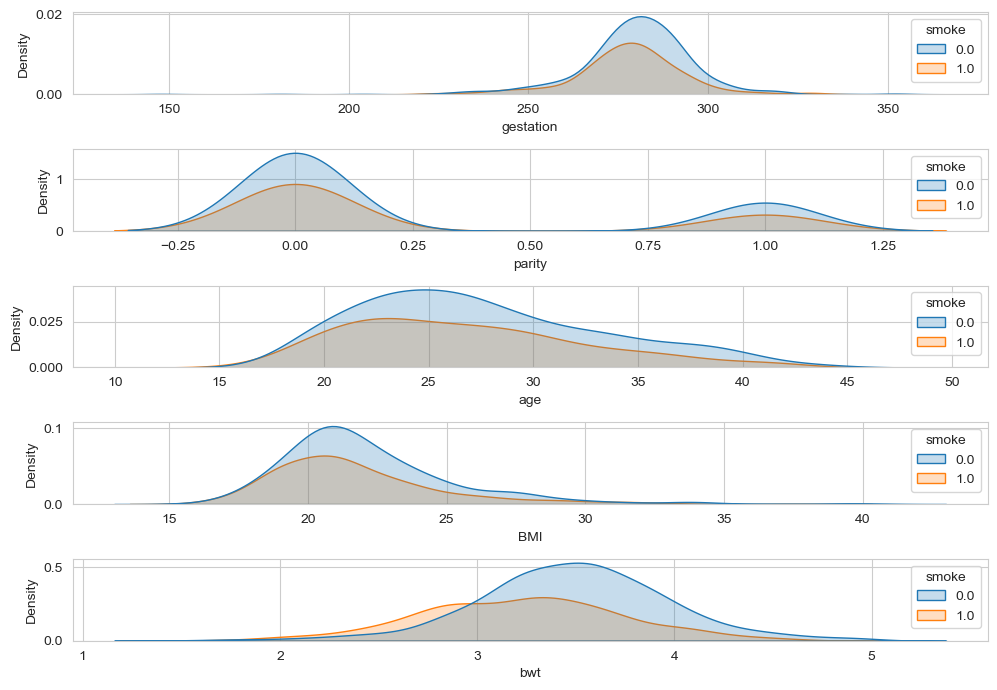

In [62]:
fig, axes = plt.subplots(nrows=len(X) + 1, ncols=1, figsize=(10,7))

for v, ax in zip(X + [Y], axes):
    sns.kdeplot(x=v, hue=T, data=df, ax=ax, fill=True)
    ax.set_xlabel(v)

plt.tight_layout()
plt.show()

Positivity assumption satisfied.

## Causal graph

We propose the following causal graph:
- `age` -> `smoke`: older mothers tend to be more educated than younger ones. As a result they may be more aware of harm caused by smoking during pregnancy and adapt their behavior accordingly. Corr: -0.06
- `age` -> `parity`: the older the mother, the less likely this his her first pregnancy. Corr: -0.35
- `age` -> `BMI`: simultaneous decrease in physical activity and lowering of metabolic activity with age leads to higher BMI. Corr: 0.17
- `parity` -> `gestation`: First pregnancies are often associated with slightly longer pregnancies due to changes in uterine and cervical characteristics after prior pregnancies. Some later pregnancies can have higher risks of preterm birth although age is a strong confounder. Corr: 0.08
- `smoke` -> `BMI`: smoking is known to cause weight loss, while quitting smoking has the opposite effect. Corr: -0.07
- `smoke` -> `gestation`: smoking during pregnancy is known to increase the chances of preterm birth.
- `smoke` -> `bwt`: smoking during pregnancy is known to impair fetal growth
- `BMI` -> `gestation`: high body mass during pregnancy may cause shorter gestation due to hormonal activity change and increase the likelihood of induced delivery due to complications (diabetes, hypertension). Corr: -0.01
- `gestion` -> `bwt`: obviously, longer gestation causes higher birth weight since the fetus has more time to develop. Corr: 0.41

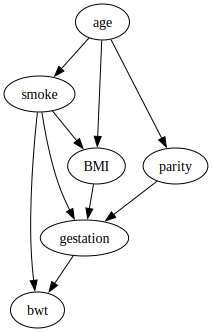

In [67]:
g = gr.Digraph()

g.edge("age", "smoke")
g.edge("age", "BMI")
g.edge("age", "parity")
g.edge("smoke", "gestation")
g.edge("smoke", "BMI")
g.edge("smoke", "bwt")
g.edge("gestation", "bwt")
g.edge("BMI", "gestation")
g.edge("parity", "gestation")
g

In [63]:
df.corr()

,bwt,gestation,parity,age,smoke,BMI
bwt,1.000000,0.407543,-0.043908,0.026983,-0.246800,0.063811
gestation,0.407543,1.000000,0.080916,-0.053425,-0.060267,-0.011891
parity,-0.043908,0.080916,1.000000,-0.351041,-0.009599,-0.129255
age,0.026983,-0.053425,-0.351041,1.000000,-0.067772,0.165408
smoke,-0.246800,-0.060267,-0.009599,-0.067772,1.000000,-0.074903
BMI,0.063811,-0.011891,-0.129255,0.165408,-0.074903,1.000000


### Backdoor criterion

We want to estimate the effect of smoking (`smoke`) on weight at birth (`bwt`). To find the admissible set, we use the backdoor criterion:
- we need to close all paths incoming to the treatment (`smoke`)
- no descendent of `smoke` should be in the set.

Following these rules, we need to observe `age`.

Assumption: Unconfoundedness / ignorability: If `U→{smoke} and U→bwt then P(bwt|smoke,age,U) = P(bwt|smoke,age)`

Although not required, we also include `parity` in the set to improve the influence of age on gestation.

In [153]:
X = ['age', 'parity']

## ATE

### Naive model

Assumptions:
- no bias
- no confounders

In [69]:
treated_mean = df[df[T] == 1][Y].mean()
control_mean = df[df[T] == 0][Y].mean()
print(f"E(bwt|smoke) = {treated_mean}")
print(f"E(bwt|~smoke) = {control_mean}")
print(f"ATE = {treated_mean - control_mean}")

E(bwt|smoke) = 3.2210825708061
E(bwt|~smoke) = 3.483314405594406
ATE = -0.2622318347883059


### Linear model

Assumptions:
- linearity
- no selection bias
- right causal model

In [104]:
model = smf.ols(T + ' ~ ' + ' + '.join(X + [T]), data=df).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-3.747e-16,3.81e-17,-9.832,0.000,-4.49e-16,-3e-16
age,6.288e-18,1.28e-18,4.915,0.000,3.78e-18,8.8e-18
parity,4.337e-17,1.69e-17,2.570,0.010,1.03e-17,7.65e-17
smoke,1.0000,1.43e-17,7e+16,0.000,1.000,1.000


ATE = -0.26 (CI: -0.32, -0.20)

### Inverse propensity resampling

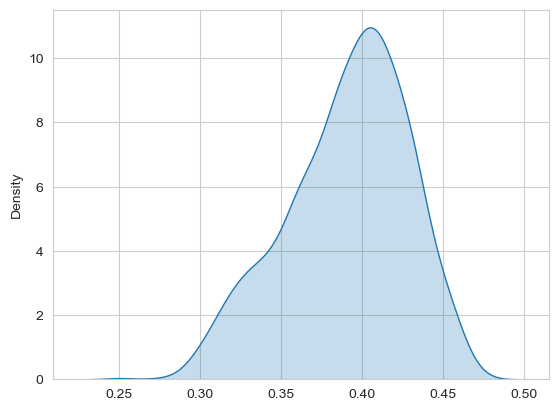

0.39097012307357565
0.3909710391822828


In [287]:
from sklearn.linear_model import LogisticRegression, LinearRegression

ps_score = LogisticRegression(C=1e6, max_iter=1000).fit(df[X], df[T]).predict_proba(df[X])[:, 1]
sns.kdeplot(data=ps_score, fill=True)
plt.show()
print(df["ps"].mean())
print(df[T].mean())

There is very little disparity in the propensity scores, so there might not be much selection bias after all.

In [285]:
df["ps"] = ps_score

### Doubly robust estimator (inverse propensity scores??)

In [156]:
def doubly_robust(df):
    ps = df["ps"]
    mu0 = LinearRegression().fit(df.query(f"{T}==0")[X], df.query(f"{T}==0")[Y]).predict(df[X])
    mu1 = LinearRegression().fit(df.query(f"{T}==1")[X], df.query(f"{T}==1")[Y]).predict(df[X])
    return np.mean(df[T]*(df[Y] - mu1)/ps + mu1) - \
        np.mean((1-df[T])*(df[Y] - mu0)/(1-ps) + mu0)
print(f"ATE = {doubly_robust(df)}")

ATE = -0.26244411845550886


In [157]:
from joblib import Parallel, delayed # for parallel processing

np.random.seed(88)
# run 1000 bootstrap samples
bootstrap_sample = 1000
ates = Parallel(n_jobs=4)(delayed(doubly_robust)(df.sample(frac=1, replace=True))
                          for _ in range(bootstrap_sample))
ates = np.array(ates)

In [158]:
print(f"ATE 95% CI: ({round(np.percentile(ates, 2.5), 2)}, {round(np.percentile(ates, 97.5), 2)})")


ATE 95% CI: (-0.32, -0.2)


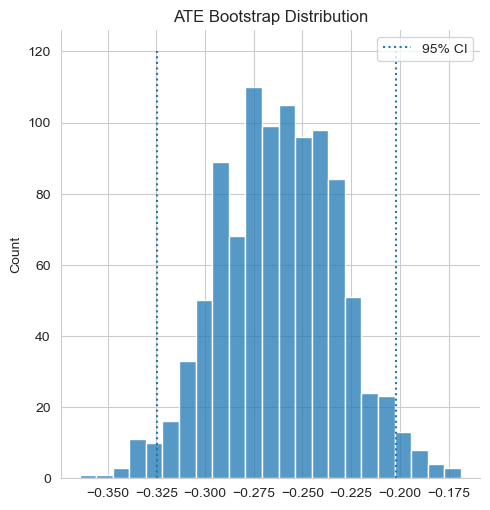

In [159]:
sns.displot(ates, kde=False)
plt.vlines(np.percentile(ates, 2.5), 0, 120, linestyles="dotted")
plt.vlines(np.percentile(ates, 97.5), 0, 120, linestyles="dotted", label="95% CI")
plt.title("ATE Bootstrap Distribution")
plt.legend();

### Debiased ML

In [349]:
np.random.seed(123)
train, test = train_test_split(df, test_size=0.4)
print(train.shape, test.shape)

(704, 7) (470, 7)


In [355]:
from sklearn.model_selection import cross_val_predict

debias_m = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)

train_pred_res = train.assign(T_res =  train[T] -
                          cross_val_predict(debias_m, train[X], train[T], cv=5))

denoise_m = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)

train_pred_res = train_pred_res.assign(Y_res =  train[Y] -
                               cross_val_predict(denoise_m, train[X], train[Y], cv=5))

final_model = smf.ols(formula='Y_res ~ T_res', data=train_pred_res).fit()
final_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0008,0.019,-0.040,0.968,-0.038,0.036
T_res,-0.2296,0.038,-6.083,0.000,-0.304,-0.155


ATE = -0.230

## CATE

In [289]:
from toolz import curry

@curry
def elast(data, y, t):
    return (np.sum((data[t] - data[t].mean())*(data[y] - data[y].mean())) /
            np.sum((data[t] - data[t].mean())**2))

def cumulative_gain(dataset, prediction, y, t, min_periods=30, steps=100):
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(min_periods, size, size // steps)) + [size]
    return np.array([elast(ordered_df.head(rows), y, t) * (rows/size) for rows in n_rows])

In [293]:
def analyze(train_pred, test_pred):
    sns.kdeplot(x="cate", data=test_pred, fill=True)
    plt.show()
    print(test_pred["cate"].median())

    sns.scatterplot(data=test_pred, x="age", y="cate", hue="parity")
    plt.show()

    gain_curve_test = cumulative_gain(test_pred, "cate", y=Y, t=T)
    gain_curve_train = cumulative_gain(train_pred, "cate", y=Y, t=T)
    plt.plot(gain_curve_test, color="C0", label="Test")
    plt.plot(gain_curve_train, color="C1", label="Train")
    plt.plot([0, 100], [0, elast(test, Y, T)], linestyle="--", color="black", label="Baseline")
    plt.legend()
    plt.show()

### Plugin estimator

In [292]:
y_star_train = train[Y] * (train[T] - train["ps"])/(train["ps"]*(1-train["ps"]))

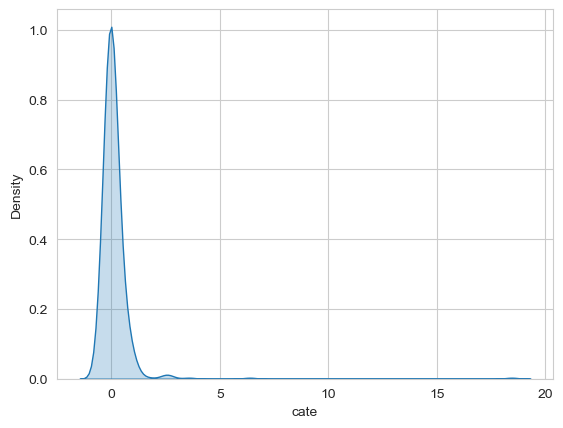

0.01348024382554236


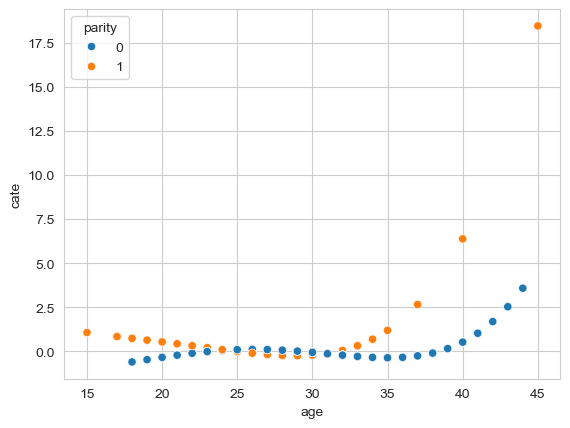

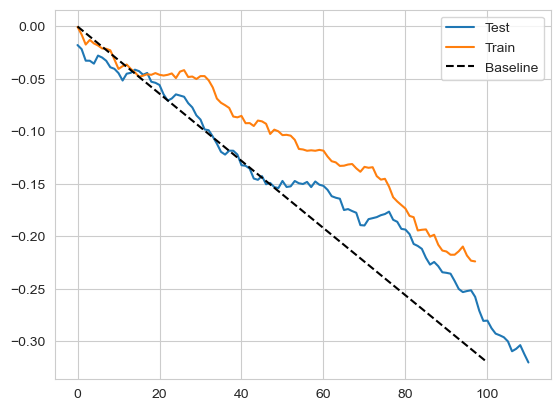

In [294]:
#cate_learner = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=300, max_leaf_nodes=5)
#cate_learner = LinearRegression()
cate_learner = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("regressor", Ridge(alpha=1.0))
])

cate_learner.fit(train[X], y_star_train)
train_pred = train.assign(cate=cate_learner.predict(train[X]))
test_pred = test.assign(cate=cate_learner.predict(test[X]))

analyze(train_pred, test_pred)

Strange that we now get a very small median effect...

These values are absurd. For older women, going from non-smoking to smoking would increase the newborn weight by a few kgs!

Does not look much better than a random guess...

### Meta learners

#### S-learner

In [295]:
np.random.seed(123)
#s_learner = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
s_learner = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("regressor", Ridge(alpha=1.0))
])
s_learner.fit(train[X+[T]], train[Y]);

C:\Users\mamar9317\AppData\Local\miniconda3\envs\causal\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.74892e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


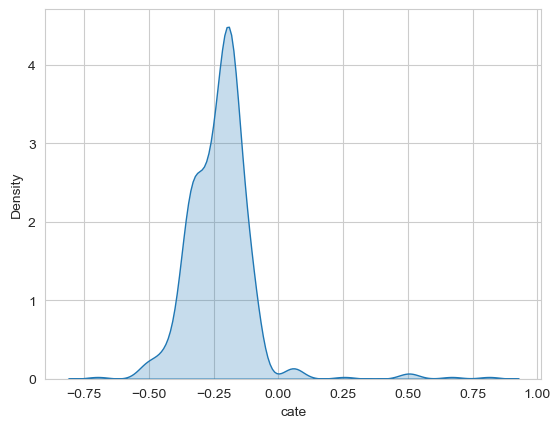

-0.21434015470361167


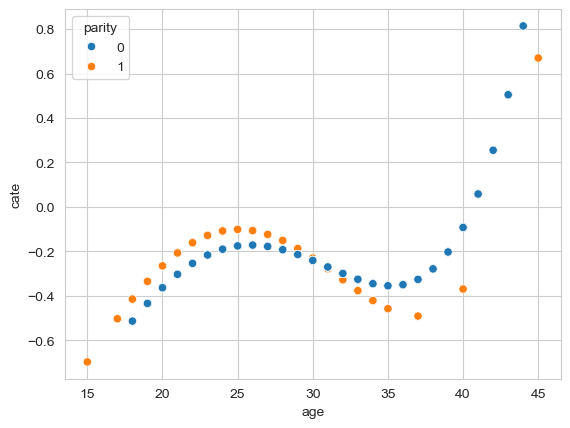

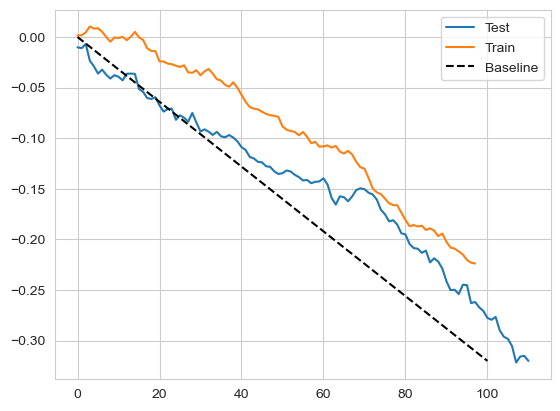

In [296]:
train_pred = train.assign(
    cate=(s_learner.predict(train[X].assign(**{T: 1})) -
                        s_learner.predict(train[X].assign(**{T: 0}))))

test_pred = test.assign(
    cate=(s_learner.predict(test[X].assign(**{T: 1})) - # predict under treatment
          s_learner.predict(test[X].assign(**{T: 0}))) # predict under control
)

analyze(train_pred, test_pred)

#### T-learner

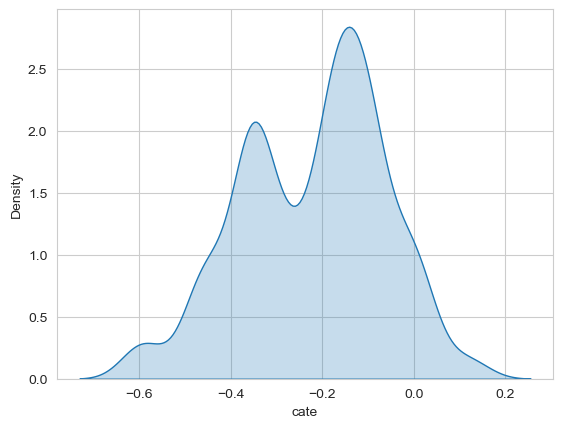

-0.17786964478097733


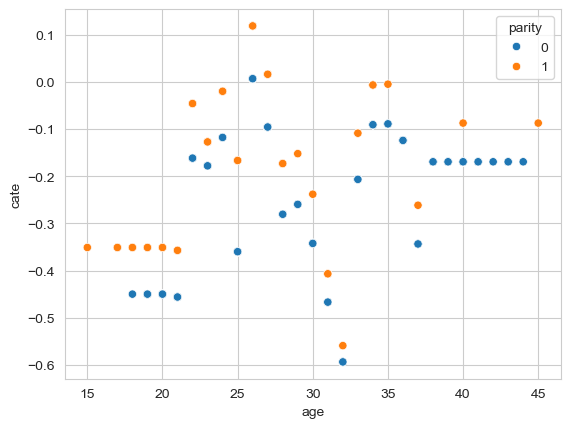

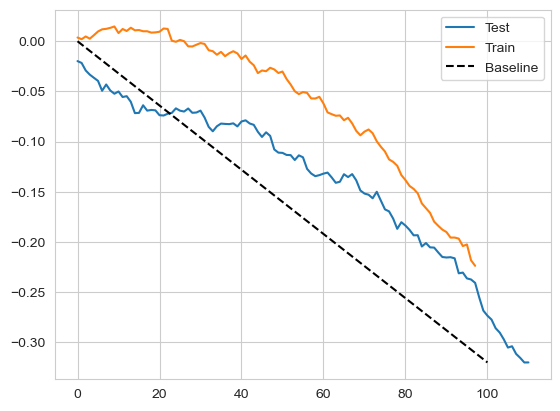

In [297]:
m0 = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
#m0 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])
m0.fit(train[X+[T]], train[Y]);

m1 = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
#m1 = Pipeline([
#    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
#    ("regressor", Ridge(alpha=1.0))
#])
m1.fit(train[X+[T]], train[Y]);

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[Y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[Y])

# estimate the CATE
train_pred = train.assign(cate=m1.predict(train[X]) - m0.predict(train[X]))
test_pred = test.assign(cate=m1.predict(test[X]) - m0.predict(test[X]))

analyze(train_pred, test_pred)

#### X-learner

In [299]:
# first stage models
#m0 = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
m0 = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("regressor", Ridge(alpha=1.0))
])
#m1 = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
m1 = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("regressor", Ridge(alpha=1.0))
])

# propensity score model
g = LogisticRegression(solver="lbfgs", penalty='l2')

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[Y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[Y])

g.fit(train[X], train[T]);

C:\Users\mamar9317\AppData\Local\miniconda3\envs\causal\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.9414e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\mamar9317\AppData\Local\miniconda3\envs\causal\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.66595e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [300]:
d_train = np.where(train[T]==0,
                   m1.predict(train[X]) - train[Y],
                   train[Y] - m0.predict(train[X]))

# second stage
#mx0 = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
mx0 = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("regressor", Ridge(alpha=1.0))
])
#mx1 = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
mx1 = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("regressor", Ridge(alpha=1.0))
])

mx0.fit(train.query(f"{T}==0")[X], d_train[train[T]==0])
mx1.fit(train.query(f"{T}==1")[X], d_train[train[T]==1]);

C:\Users\mamar9317\AppData\Local\miniconda3\envs\causal\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.9414e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\mamar9317\AppData\Local\miniconda3\envs\causal\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.66595e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


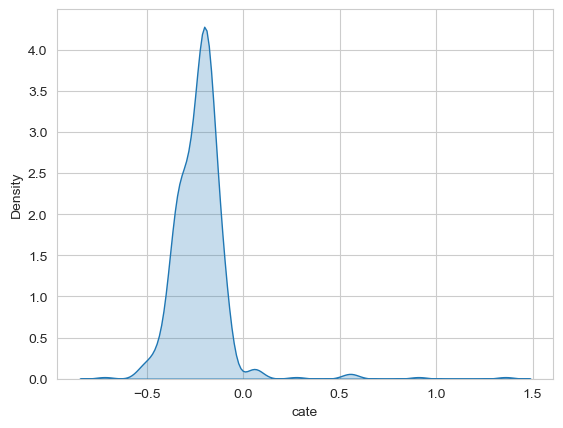

-0.21684216305837467


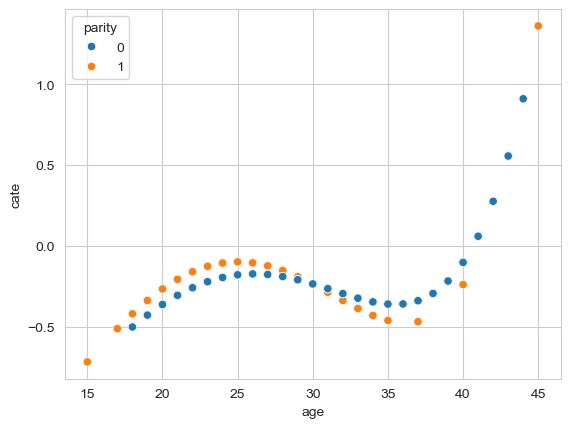

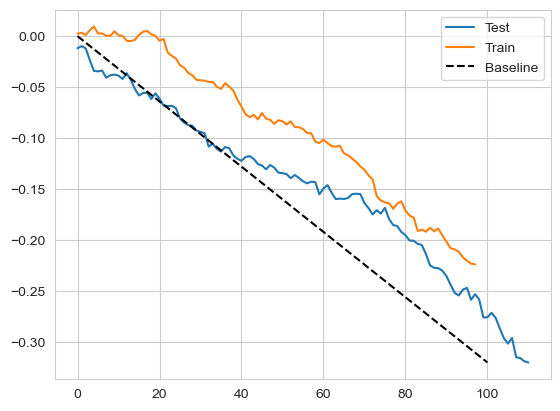

In [302]:
def ps_predict(df, t):
    return g.predict_proba(df[X])[:, t]


train_pred = train.assign(cate=(ps_predict(train,1)*mx0.predict(train[X]) +
                ps_predict(train,0)*mx1.predict(train[X])))

test_pred = test.assign(cate=(ps_predict(test,1)*mx0.predict(test[X]) +
                                ps_predict(test,0)*mx1.predict(test[X])))

analyze(train_pred, test_pred)

### Debiased ML

#### R learner

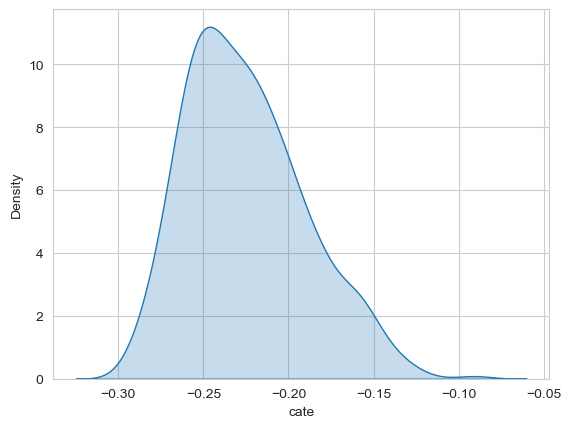

-0.23059571679979216


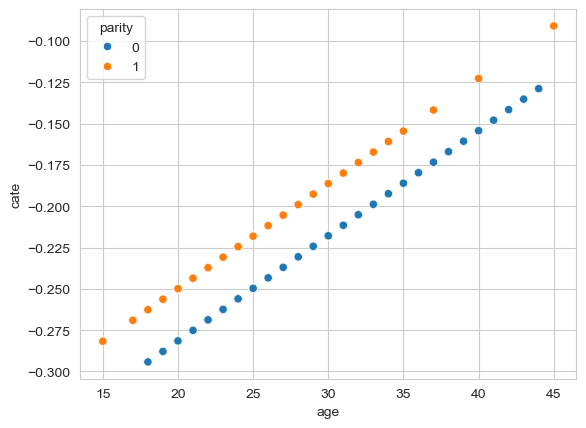

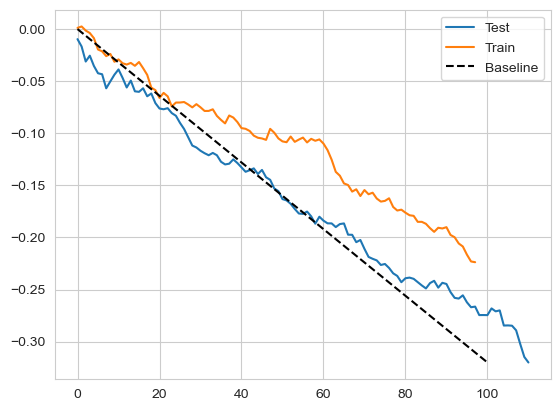

In [357]:
final_model_cate = smf.ols(formula='Y_res ~ T_res * (age + parity)', data=train_pred_res).fit()

debias_m = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
debias_m.fit(train[X], train[Y])

test_pred_res = test.assign(T_res =  test[T] -
                          debias_m.predict(test[X])
                          + test[T].mean()) # add mu_t for visualization.

denoise_m = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)
denoise_m.fit(train[X], train[Y])

test_pred_res = test_pred_res.assign(Y_res =  test[Y] -
                               denoise_m.predict(test[X])
                               + test[Y].mean())

train_pred = train.assign(cate=final_model_cate.predict(train_pred_res.assign(T_res=1))
                        - final_model_cate.predict(train_pred_res.assign(T_res=0)))
test_pred = test.assign(cate=final_model_cate.predict(test_pred_res.assign(T_res=1))
                        - final_model_cate.predict(test_pred_res.assign(T_res=0)))
analyze(train_pred, test_pred)

### Non-parametric DML

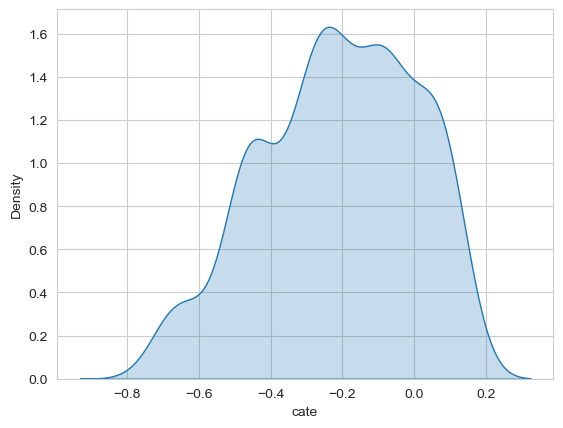

-0.20367313835910722


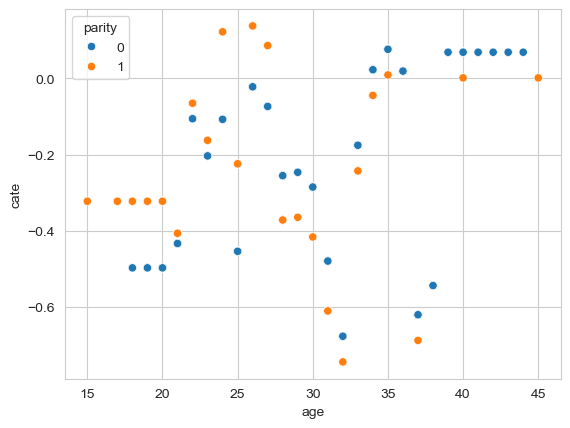

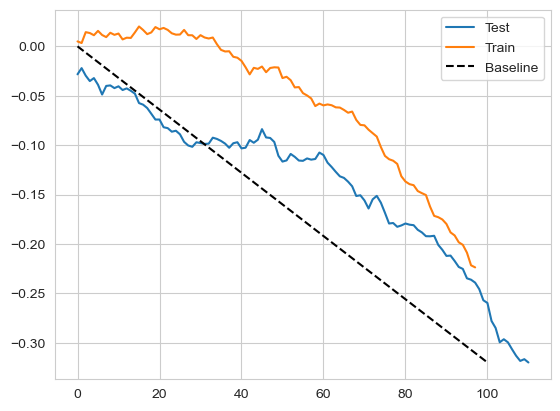

In [358]:
model_final = HistGradientBoostingRegressor(max_depth=3, min_samples_leaf=30, max_leaf_nodes=5)

# create the weights
w = train_pred_res["T_res"] ** 2

# create the transformed target
y_star = (train_pred_res["Y_res"] / train_pred_res["T_res"])

# use a weighted regression ML model to predict the target with the weights.
model_final.fit(X=train[X], y=y_star, sample_weight=w)

train_pred = train.assign(cate=model_final.predict(train[X]))
test_pred = test.assign(cate=model_final.predict(test[X]))
analyze(train_pred, test_pred)